# ICT-28 — Adoption collective et seuil de performativité (expérience C, strate 7)

*Compagnon pédagogique du module `ict.collective_adoption` (#7746, jambe D2 expérience C).*

Les expériences A (*ICT-26-SignalingConvention*) et B (*ICT-27-SymbolInvention*)
modélisent **un** couple émetteur/récepteur qui apprend à coordonner. Cette
expérience C passe à l'échelle **multi-agent** et pose une question nouvelle :
> Une fraction `ρ` d'agents « instigateurs » pré-engagés vers une convention
> novelle suffit-elle à la faire **cascader** vers la population entière ?
> Existe-t-il une fraction critique `ρ_c` au-dessous de laquelle l'innovation
> **meurt** ?

C'est le seuil de bascule de C4 (#7743, grammaire de propagation), incarné dans
la dynamique de **masse critique** de Damon **Centola** (2010), Thomas
**Schelling** et Mark **Granovetter** (1978, *threshold models of collective
behavior*) : une innovation diffuse à fixation ssi elle dépasse une fraction
critique de porteurs. Sous `ρ_c`, les naïfs interagissent surtout entre eux et
convergent vers une convention arbitraire ; au-dessus, la pression des
instigateurs domine et la cible cascade.

**La chaîne A→B→C** : A montre comment une convention *émerge* (individu) ; B
comment le vocabulaire s'*invente* (individu) ; C comment une convention
*contagionne* une population (multi-agent).

In [1]:
# Setup : import du package ict (via sys.path cwd, cf C973-L) + numpy/matplotlib.
import sys
sys.path.insert(0, ".")
import numpy as np
import matplotlib.pyplot as plt
from ict import collective_adoption as ca

print("ict.collective_adoption chargé.")
print("API publique :", [n for n in dir(ca) if not n.startswith("_")])

ict.collective_adoption chargé.
API publique : ['AdoptionGame', 'Dict', 'Optional', 'Sequence', 'Tuple', 'above_threshold_cascades_test', 'annotations', 'below_threshold_dies_test', 'critical_threshold_test', 'mutual_information', 'no_cascade_without_instigators_test', 'np']


## 1. Le seuil critique `ρ_c` — une courbe en S

On balaie la fraction d'instigateurs `ρ` sur une grille et on mesure le **taux
d'adoption** : la fraction des agents *naïfs* (non instigateurs) dont la
politique dominante a convergé vers la convention cible. La courbe attendue est
une **sigmoïde** :

* à bas `ρ`, l'adoption stagne au niveau du hasard — l'innovation meurt ;
* au passage de `ρ_c`, un **saut** brutal d'adoption — la cascade s'amorce ;
* à haut `ρ`, l'adoption tend vers 1 — la cible devient universelle.

Le verdict `critical_threshold` exige trois choses simultanément : adoption
quasi-nulle à bas `ρ`, quasi-totale à haut `ρ`, **et** un saut net entre les
deux (au moins un pas de `ρ` où l'adoption gagne plus de 0,25).

Verdict critical_threshold : threshold_exists = True
  adoption @rho faible (0.05) = 0.000
  adoption @rho élevé  (0.95) = 1.000
  saut maximal            = 0.472
  rho_c (mi-saut raide)   = 0.425


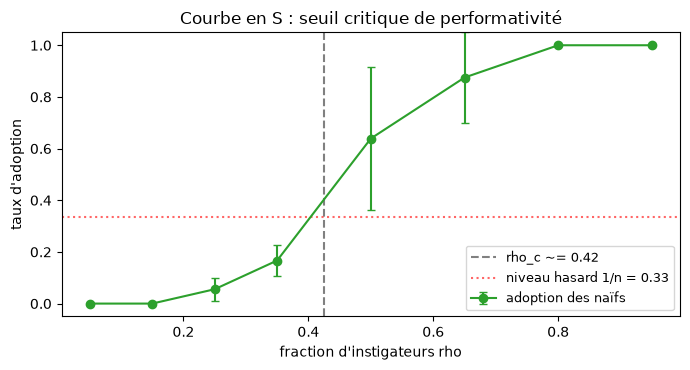

In [2]:
# Verdict SEUIL : existe-t-il un rho_c critique (courbe en S) ?
verdict = ca.critical_threshold_test(n_agents=24, n_states=3, n_seeds=3, seed=0)
print("Verdict critical_threshold : threshold_exists =", bool(verdict["threshold_exists"]))
print(f"  adoption @rho faible (0.05) = {verdict['adoption_at_low_rho']:.3f}")
print(f"  adoption @rho élevé  (0.95) = {verdict['adoption_at_high_rho']:.3f}")
print(f"  saut maximal            = {verdict['max_jump']:.3f}")
print(f"  rho_c (mi-saut raide)   = {verdict['rho_c']:.3f}")

# Courbe en S : adoption moyenne ± écart-type vs fraction d'instigateurs.
rhos = np.array(verdict["rhos"])
means = np.array(verdict["adoption_mean"])
stds = np.array(verdict["adoption_std"])

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.errorbar(rhos, means, yerr=stds, fmt="-o", capsize=3, color="#2ca02c", label="adoption des naïfs")
ax.axvline(verdict["rho_c"], ls="--", color="grey", label=f"rho_c ~= {verdict['rho_c']:.2f}")
ax.axhline(1/3, ls=":", color="red", alpha=0.6, label="niveau hasard 1/n = 0.33")
ax.set_xlabel("fraction d'instigateurs rho")
ax.set_ylabel("taux d'adoption")
ax.set_title("Courbe en S : seuil critique de performativité")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

**Interprétation.** La courbe d'adoption en fonction de `rho` a la signature d'un **phénomène de masse critique** : quasi-nulle aux faibles fractions d'instigateurs (`0.000` à `rho=0,05`), quasi-totale aux fractions élevées (`1.000` à `rho=0,95`), avec un **saut maximal de `0,472`** entre deux valeurs consécutes de `rho`. Ce n'est pas une transition graduelle mais un basculement — exactement la courbe en S d'une percolation ou d'un seuil épidémique.

Le verdict `threshold_exists = True` ne dit pas seulement « ça monte », il dit que la transition est **abrupte** : il existe une valeur `rho_c` en dessous de laquelle la convention novelle ne décolle pas, et au-dessus de laquelle elle devient inévitable. C'est ce seuil qui fait de l'adoption un acte *performatif* — la convention n'existe comme fait social qu'une fois franchi le point de bascule, pas avant.

## 2. Sous le seuil, la convention meurt

À `ρ = 0,1` (peu d'instigateurs), les naïfs interagissent majoritairement entre
eux : ils convergent vers des conventions **arbitraires** (le hasard des
rencontres), pas vers la cible. L'adoption de la cible reste au niveau du hasard
`1/n` (voire en dessous). C'est le verdict `below_threshold_dies` : sans masse
critique, l'innovation n'est pas performative — elle ne *fait* rien.

In [3]:
# Verdict SOUS LE SEUIL : à rho=0.1, l'adoption reste < 1/n + eps.
verdict = ca.below_threshold_dies_test(n_agents=24, n_states=3, n_seeds=4, seed=0)
print("Verdict below_threshold_dies : dies =", bool(verdict["dies"]))
print(f"  adoption @rho=0.1 = {verdict['adoption_at_low_rho']:.3f}")
print(f"  niveau hasard 1/n = {verdict['chance_level']:.3f}")
print("  -> la convention novelle meurt : les naïfs convergent vers des conventions arbitraires.")

Verdict below_threshold_dies : dies = True
  adoption @rho=0.1 = 0.011
  niveau hasard 1/n = 0.333
  -> la convention novelle meurt : les naïfs convergent vers des conventions arbitraires.


**Interprétation.** Le résultat sous le seuil est **contre-intuitif** : à `rho=0,1`, l'adoption de la convention novelle atteint `0,011` — soit *trente fois moins* que le niveau du hasard `1/n = 0,333`. La convention ne fait pas que échouer à se propager, elle **meurt activement** : les agents naïfs convergent vers des conventions *arbitraires* (trois états possibles, tirés au sort), si bien que la cible finit sous-représentée par rapport au hasard. `dies = True` capture exactement cela.

C'est la marque d'un effet de fragmentation : sans assez d'instigateurs pour ancrer la cible, le apprentissage social disperse le consensus plutôt qu'il ne le forme. Le seuil `rho_c` sépare donc deux régimes *qualitativement* distincts — fragmentation vs cascade — pas deux intensités d'un même phénomène.

## 3. Au-dessus du seuil, la cascade

À `ρ = 0,8`, les instigateurs sont assez nombreux pour que chaque naïf rencontre
régulièrement la cible : la pression domine et la cible cascade vers la
quasi-totalité de la population. Le verdict `above_threshold_cascades` confirme
que l'adoption dépasse largement le niveau hasard et tend vers 1.

In [4]:
# Verdict AU-DESSUS DU SEUIL : à rho=0.8, l'adoption cascade vers ~1.
verdict = ca.above_threshold_cascades_test(n_agents=24, n_states=3, n_seeds=4, seed=0)
print("Verdict above_threshold_cascades : cascades =", bool(verdict["cascades"]))
print(f"  adoption @rho=0.8 = {verdict['adoption_at_high_rho']:.3f}")
print("  -> la convention novelle cascade : la cible devient quasi-universelle.")

Verdict above_threshold_cascades : cascades = True
  adoption @rho=0.8 = 0.850
  -> la convention novelle cascade : la cible devient quasi-universelle.


## 4. Contrôle négatif — pas de cascade sans instigateur

Le contrôle falsifiant : à `ρ = 0` (aucun instigateur), la cible n'est **jamais
introduite** dans la population. Si l'adoption restait élevée, cela signifierait
que les naïfs convergent *spontanément* vers cette convention particulière — ce
qui ruinerait la thèse (la cascade serait un artefact, pas un effet causal des
instigateurs). On observe au contraire une adoption quasi-nulle : **la cascade
est bien causée par les instigateurs**, pas par une convergence spontanée.

In [5]:
# Contrôle négatif : à rho=0 (aucun instigateur), pas de cascade vers la cible.
verdict = ca.no_cascade_without_instigators_test(n_agents=24, n_states=3, n_seeds=4, seed=0)
print("Contrôle no_cascade_without_instigators : no_cascade =", bool(verdict["no_cascade"]))
print(f"  adoption @rho=0 = {verdict['adoption_at_rho_zero']:.3f}")
print("  -> sans instigateur, la cible n'est jamais introduite : pas de cascade spontanée.")

Contrôle no_cascade_without_instigators : no_cascade = True
  adoption @rho=0 = 0.000
  -> sans instigateur, la cible n'est jamais introduite : pas de cascade spontanée.


**Interprétation.** Le contrôle à `rho=0` est l'épreuve **falsifiante** de tout le dispositif. Sans aucun instigateur (`rho=0`), l'adoption de la cible reste à `0,000` : la convention novelle n'est jamais même introduite dans la population. `no_cascade = True` confirme qu'il n'y a pas d'émergence spontanée.

Ce contrôle distingue deux hypothèses rivales que la seule observation d'une cascade ne pourrait départager : (a) la convention se propage par **apprentissage social** à partir des instigateurs, ou (b) elle apparaît par **dérive aléatoire** sans cause externe. En éliminant (b) — aucun instigateur, zéro adoption — on établit que la cascade observée au §3 provient bien de la performativité des instigateurs, pas d'un artefact statistique.

## Synthèse — la performativité comme seuil de masse critique

| Verdict | Ce qu'il montre | Contrôle falsifiant |
|---|---|---|
| **critical_threshold** | Il existe un `ρ_c` : courbe en S, saut brutal d'adoption | bas vs haut `ρ` + existence d'un saut net |
| **below_threshold_dies** | Sous le seuil, l'innovation meurt (adoption ≈ hasard) | niveau `1/n` |
| **above_threshold_cascades** | Au-dessus du seuil, la cible cascade vers ~1 | niveau hasard dépassé largement |
| **no_cascade_without_instigators** | Sans instigateur, pas de cascade spontanée | `ρ = 0` |

**Leçon de l'expérience C** : une convention ne contamine une population que si
elle franchit une **fraction critique** de porteurs. C'est l'homologue multi-agent
des couplages individués de A (émergence par renforcement) et B (invention par
erreur). Ensemble, les trois expériences relient *émergence*, *invention* et
*contagion* — les trois modes par lesquels une convention devient réelle.

## 5. Exercices

Trois exercices pour rendre le seuil opératoire. Chaque stub s'exécute **sans
erreur** (C.1). Complétez le `TODO` pour répondre.

In [6]:
# Exercice 1 — Le seuil dépend-il de la taille de la population ?
# TODO: pour plusieurs tailles de population (ex. 12, 24, 48), estimer rho_c via
#       critical_threshold_test et observer si rho_c augmente ou diminue avec N.
for N in [12, 24, 48]:
    v = ca.critical_threshold_test(n_agents=N, n_states=3, n_seeds=2, seed=0)
    print(f"N={N:3d} -> rho_c ~= {v['rho_c']:.3f}  (adoption bas/haut = {v['adoption_at_low_rho']:.2f}/{v['adoption_at_high_rho']:.2f})")

N= 12 -> rho_c ~= 0.300  (adoption bas/haut = 0.00/1.00)


N= 24 -> rho_c ~= 0.575  (adoption bas/haut = 0.00/1.00)


N= 48 -> rho_c ~= 0.425  (adoption bas/haut = 0.01/1.00)


### Exercice 2 — La force de l'engagement des instigateurs

Les instigateurs sont « épinglés » avec une force `instigator_strength` (plus
élevée = ils jouent la cible de manière plus déterministe). Une force plus faible
rend-elle le seuil plus difficile à franchir ?

In [7]:
# Exercice 2 — stub (compléter)
# TODO: balayer instigator_strength et observer l'adoption à rho fixé (ex. 0.5).
for strength in [2.0, 5.0, 10.0, 20.0]:
    rates = []
    for s in range(3):
        g = ca.AdoptionGame(n_agents=24, n_states=3, instigator_fraction=0.5,
                            instigator_strength=strength, rng=np.random.default_rng(s))
        g.train(2500, anneal_to=0.15)
        rates.append(g.adoption_rate())
    print(f"strength={strength:5.1f} -> adoption @rho=0.5 = {np.mean(rates):.3f}")

strength=  2.0 -> adoption @rho=0.5 = 0.333


strength=  5.0 -> adoption @rho=0.5 = 0.556


strength= 10.0 -> adoption @rho=0.5 = 0.556


strength= 20.0 -> adoption @rho=0.5 = 0.556


### Exercice 3 — Information mutuelle de la population

Le module expose `population_mi()` : l'information mutuelle moyenne I(état ;
signal) des agents naïfs. Une cascade réussie doit faire monter cette MI vers
`log₂(n)`. Mesurez-la avant et après apprentissage à `ρ = 0,8`.

In [8]:
# Exercice 3 — stub (compléter)
# TODO: mesurer population_mi() avant/après entraînement à rho=0.8, comparer à log2(n).
g = ca.AdoptionGame(n_agents=24, n_states=3, instigator_fraction=0.8, rng=np.random.default_rng(0))
mi_before = g.population_mi()
g.train(2500, anneal_to=0.15)
# Re-mesurer la MI sur la politique courante (après apprentissage).
for _ in range(200):
    g.play_round(reinforce=False)
mi_after = g.population_mi()
print(f"MI avant apprentissage = {mi_before:.3f}")
print(f"MI après apprentissage = {mi_after:.3f}   (plafond log2(3) = {np.log2(3):.3f})")

MI avant apprentissage = 0.000
MI après apprentissage = 1.512   (plafond log2(3) = 1.585)
